In [2]:
import numpy as np 
import scipy.stats as st
import pymc as pm
import matplotlib.pyplot as plt 
import arviz as az 
import pickle 
import pytensor.tensor as pt
import pytensor.scan as scan
import pytensor
from pytensor.printing import Print
from pytensor import function
import corner 

In [3]:
Nobs=10000

In [ ]:
np.random.seed(123)
def plotter2(x_obs,y_obs,x_name,y_name):
    fig = plt.figure(figsize=(8, 8))
    grid = plt.GridSpec(4, 4, hspace=0.4, wspace=0.4)
    main_ax = fig.add_subplot(grid[1:4, 0:3])
    main_ax.scatter(x_obs, y_obs, alpha=0.6, color='darkorange', s=25)
    main_ax.set_title("Scatter Plot of "+x_name+" vs "+ y_name , fontsize=14)
    main_ax.set_xlabel(x_name, fontsize=12)
    main_ax.set_ylabel(y_name, fontsize=12)
    main_ax.grid(True, linestyle='--', alpha=0.6)

    x_hist = fig.add_subplot(grid[0, 0:3], sharex=main_ax)
    x_hist.hist(x_obs, bins=30, color='gold', edgecolor='k')
    x_hist.set_title("Histogram of "+x_name, fontsize=12)
    x_hist.grid(True, linestyle='--', alpha=0.5)

    y_hist = fig.add_subplot(grid[1:4, 3], sharey=main_ax)
    y_hist.hist(y_obs, bins=30, orientation='horizontal', color='tomato', edgecolor='k')
    y_hist.set_title("Histogram of  "+y_name, fontsize=12)
    y_hist.grid(True, linestyle='--', alpha=0.5)

    plt.show()
def plotter1(x,x_name):
    plt.hist(x,bins=50,color='blue')
    plt.title("Histogram of "+x_name)
    plt.xlabel(x_name)
    plt.ylabel("Pm("+x_name+")")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

True variable Generation:
$$

\begin{pmatrix}
x_i \\
y_i
\end{pmatrix}
\sim
\mathcal{N}
\left(
\begin{pmatrix}
\mu_x \\
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 & \rho\,\sigma_x\sigma_y \\
\rho\,\sigma_x\sigma_y & \sigma_y^2
\end{pmatrix}
\right)
$$

In [ ]:
mu_t_x=1
mu_t_y=1
sigma_t_y=2
sigma_t_x=2
p_t=0.8
cov = [
    [sigma_t_x**2, p_t * sigma_t_x * sigma_t_y],
    [p_t * sigma_t_x * sigma_t_y, sigma_t_y**2]
]
mean = [mu_t_x, mu_t_y]

x, y = np.random.multivariate_normal(mean, cov, Nobs).T

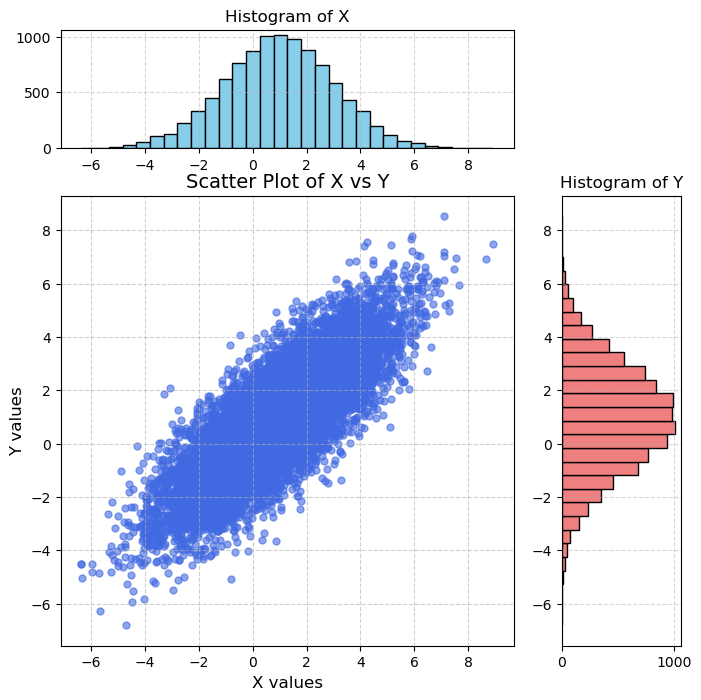

In [ ]:

fig = plt.figure(figsize=(8, 8))
grid = plt.GridSpec(4, 4, hspace=0.4, wspace=0.4)

main_ax = fig.add_subplot(grid[1:4, 0:3])
main_ax.scatter(x, y, alpha=0.6, color='royalblue', s=25)
main_ax.set_title("Scatter Plot of X vs Y", fontsize=14)
main_ax.set_xlabel("X values", fontsize=12)
main_ax.set_ylabel("Y values", fontsize=12)
main_ax.grid(True, linestyle='--', alpha=0.6)

x_hist = fig.add_subplot(grid[0, 0:3], sharex=main_ax)
x_hist.hist(x, bins=30, color='skyblue', edgecolor='k')
x_hist.set_title("Histogram of X", fontsize=12)
x_hist.grid(True, linestyle='--', alpha=0.5)
y_hist = fig.add_subplot(grid[1:4, 3], sharey=main_ax)
y_hist.hist(y, bins=30, orientation='horizontal', color='lightcoral', edgecolor='k')
y_hist.set_title("Histogram of Y", fontsize=12)
y_hist.grid(True, linestyle='--', alpha=0.5)

plt.show()

Observed Variable Generation : 

$$
\begin{pmatrix}
x_i^{\mathrm{obs}} \\
y_i^{\mathrm{obs}}
\end{pmatrix}
\sim
\mathcal{N}
\left(
\begin{pmatrix}
x_i \\
y_i
\end{pmatrix},
\begin{pmatrix}
\sigma_{x,i}^2 & \rho_2\,\sigma_{x,i}\sigma_{y,i} \\
\rho_2\,\sigma_{x,i}\sigma_{y,i} & \sigma_{y,i}^2
\end{pmatrix}
\right)
$$

Imposing truncation , that is , we are defining a region in the x-y plane where our observed variable can exist.
Here the region is defined as 
$$
\mathcal{Region} \equiv x_i^{obs}>0 \text{  and  } y_i^{obs}>0
$$


$$
\textbf{Now observed Quantities}
$$
$$
Y_i^{\text{obs}},X_i^{\text{obs}},\sigma_{Y_i}^{\text{obs}},\sigma_{X_i}^{\text{obs}},\rho_2

$$
$$


In [7]:
x_obs = np.zeros(Nobs)
y_obs = np.zeros(Nobs)
sigma_obs_y = abs(np.random.normal(3, 2, Nobs))*0+2
sigma_obs_x = abs(np.random.normal(3, 2, Nobs))*0+2
p2 = 0.8  

for i in range(Nobs):
    cov = [
        [sigma_obs_x[i]**2,              p2 * sigma_obs_x[i] * sigma_obs_y[i]],
        [p2 * sigma_obs_x[i] * sigma_obs_y[i], sigma_obs_y[i]**2]
    ]
    mean = [x[i], y[i]]    # intrinsic x,y for point i

    x_temp, y_temp = np.random.multivariate_normal(mean, cov)
    x_obs[i], y_obs[i] = x_temp, y_temp

mask = (x_obs > 0) & (y_obs > 0)


x_obs        = x_obs[mask]
y_obs        = y_obs[mask]
sigma_obs_x1 = sigma_obs_x[mask]
sigma_obs_y1 = sigma_obs_y[mask]
sigma_obs_x=np.mean(sigma_obs_x1)
sigma_obs_y=np.mean(sigma_obs_y1)
     




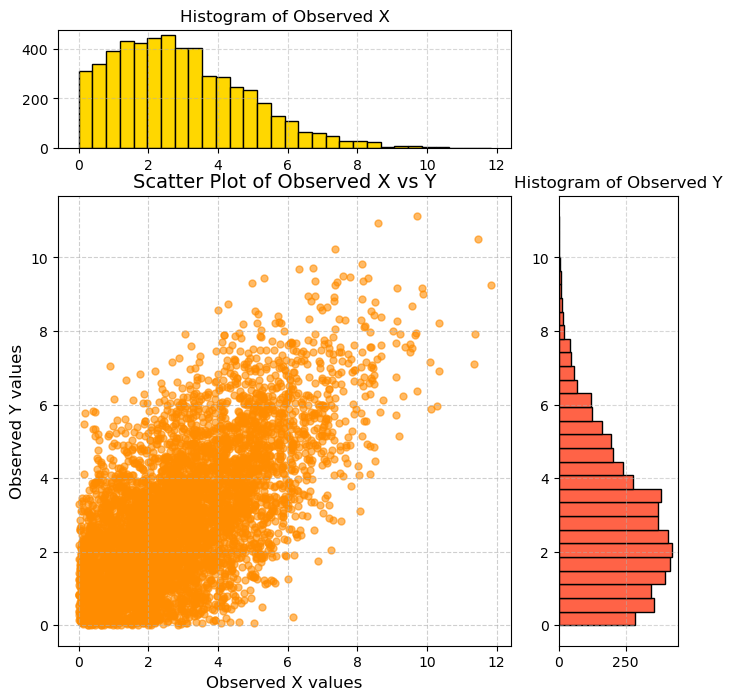

In [ ]:
fig = plt.figure(figsize=(8, 8))
grid = plt.GridSpec(4, 4, hspace=0.4, wspace=0.4)
main_ax = fig.add_subplot(grid[1:4, 0:3])
main_ax.scatter(x_obs, y_obs, alpha=0.6, color='darkorange', s=25)
main_ax.set_title("Scatter Plot of Observed X vs Y", fontsize=14)
main_ax.set_xlabel("Observed X values", fontsize=12)
main_ax.set_ylabel("Observed Y values", fontsize=12)
main_ax.grid(True, linestyle='--', alpha=0.6)

x_hist = fig.add_subplot(grid[0, 0:3], sharex=main_ax)
x_hist.hist(x_obs, bins=30, color='gold', edgecolor='k')
x_hist.set_title("Histogram of Observed X", fontsize=12)
x_hist.grid(True, linestyle='--', alpha=0.5)

y_hist = fig.add_subplot(grid[1:4, 3], sharey=main_ax)
y_hist.hist(y_obs, bins=30, orientation='horizontal', color='tomato', edgecolor='k')
y_hist.set_title("Histogram of Observed Y", fontsize=12)
y_hist.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [9]:
Nobs=len(y_obs)
print(Nobs)

5369


<ErrorbarContainer object of 3 artists>

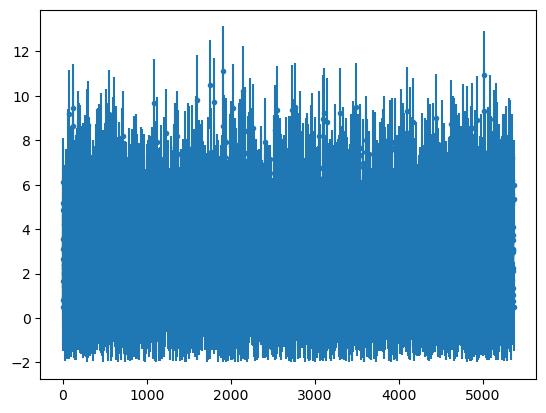

In [10]:
plt.errorbar(np.arange(0,Nobs,1), y_obs, yerr=sigma_obs_y, fmt='.', label='data')

<ErrorbarContainer object of 3 artists>

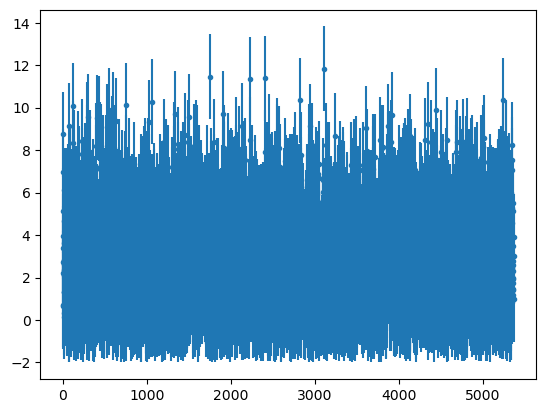

In [11]:
plt.errorbar(np.arange(0,Nobs,1), x_obs, yerr=sigma_obs_x, fmt='.', label='data')

In [12]:
cov3=np.cov(x_obs,y_obs)[0,1]/(np.std(x_obs)*np.std(y_obs))
print(cov3)

0.6451559184743977



$$
\textbf{Priors}
$$

$$
\mu_x \sim \mathcal{U}(-5, 5)
$$
$$
\mu_y \sim \mathcal{U}(-5, 5)
$$
$$
\sigma_x \sim \mathcal{U}(0, 10)
$$
$$
\sigma_y \sim \mathcal{U}(0, 10)
$$


$$
\textbf{Full Likelihood Expression}
$$

$$
\vec{\Omega} = (\mu_x, \mu_y, \sigma_x, \sigma_y, \rho)
$$

$$
P(\vec{\Omega} \, | \, \vec{x}^{\, \mathrm{obs}}, \vec{y}^{\, \mathrm{obs}}) 
\propto P(\vec{x}^{\, \mathrm{obs}}, \vec{y}^{\, \mathrm{obs}} \, | \, \vec{\Omega}) \, P(\vec{\Omega})
$$

$$
\mathcal{L}(\vec{x}^{\, \mathrm{obs}}, \vec{y}^{\, \mathrm{obs}} \, | \, \vec{\Omega}) 
= \prod_{i=1}^{N_{\mathrm{obs}}} 
\iint P(x_i^{\, \mathrm{obs}}, y_i^{\, \mathrm{obs}} \, | \, x_i,y_i) 
P(x_i, y_i \, | \, \vec{\Omega}) \, dx_i \, dy_i
$$


Now truncating such that $x_{obs},y_{obs} \in \mathcal{Region}$, where the region is arbritary
$$
\mathcal{L}(\vec{x}^{\,\mathrm{obs}}, \vec{y}^{\,\mathrm{obs}} \mid \vec{\Omega})
= \prod_{i=1}^{N_{\mathrm{obs}}} \frac{


\mathcal{N}_{x_i^{\mathrm{obs}},y_i^{\mathrm{obs}}}
\!\left(
\begin{pmatrix}
\mu_x \\[4pt]
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 + (\sigma_{x,i}^{\mathrm{obs}})^2
&
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
\\[6pt]
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
&
\sigma_y^2 + (\sigma_{y,i}^{\mathrm{obs}})^2
\end{pmatrix}
\right)}
{
    \displaystyle \iint_{x_{obs},y_{obs} \in \mathcal{Region}} 


\mathcal{N}_{x_i^{\mathrm{obs}},y_i^{\mathrm{obs}}}
\!\left(
\begin{pmatrix}
\mu_x \\[4pt]
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 + (\sigma_{x,i}^{\mathrm{obs}})^2
&
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
\\[6pt]
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
&
\sigma_y^2 + (\sigma_{y,i}^{\mathrm{obs}})^2
\end{pmatrix}
\right) dx_{obs}dy_{obs}
}
$$
$$
or, \text{     }\mathcal{L}(\vec{x}^{\,\mathrm{obs}}, \vec{y}^{\,\mathrm{obs}} \mid \vec{\Omega})
= \prod_{i=1}^{N_{\mathrm{obs}}} \frac{
\mathcal{N}_{x_i^{\mathrm{obs}},y_i^{\mathrm{obs}}}
\!\left(
\begin{pmatrix}
\mu_x \\[4pt]
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 + (\sigma_{x,i}^{\mathrm{obs}})^2
&
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
\\[6pt]
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
&
\sigma_y^2 + (\sigma_{y,i}^{\mathrm{obs}})^2
\end{pmatrix}
\right)}
{
    \displaystyle \iint_{x_{obs},y_{obs} \in \mathcal{Region}} 
\mathcal{N}_{x_i^{\mathrm{obs}},y_i^{\mathrm{obs}}}
\!\left(
\begin{pmatrix}
\mu_x \\[4pt]
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 + (\sigma_{x,i}^{\mathrm{obs}})^2
&
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
\\[6pt]
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
&
\sigma_y^2 + (\sigma_{y,i}^{\mathrm{obs}})^2
\end{pmatrix}
\right) dx_{obs}dy_{obs}
}
$$


Posterior :
$$
P\left(\Omega \mid x^{\text{obs}}, y^{\text{obs}}, \sigma_y^{\text{obs}}, \sigma_x^{\text{obs}}\right)
\propto
P(\Omega) \, \mathcal{L}(x^{\text{obs}}, y^{\text{obs}} \sigma_y^{\text{obs}}, \sigma_x^{\text{obs}}\mid \Omega)
$$
$$
P\left(\Omega \mid x^{\text{obs}}, y^{\text{obs}}, \sigma_y^{\text{obs}}, \sigma_x^{\text{obs}}\right)
\propto
P(\mu_X)P(\mu_Y) P(\sigma_X) P(\sigma_Y) \, \\ \times \prod_{i=1}^{N_{\mathrm{obs}}} \frac{
\mathcal{N}_{x_i^{\mathrm{obs}},y_i^{\mathrm{obs}}}
\!\left(
\begin{pmatrix}
\mu_x \\[4pt]
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 + (\sigma_{x,i}^{\mathrm{obs}})^2
&
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
\\[6pt]
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
&
\sigma_y^2 + (\sigma_{y,i}^{\mathrm{obs}})^2
\end{pmatrix}
\right)}
{
    \displaystyle \iint_{x_{obs},y_{obs} \in \mathcal{Region}} 
\mathcal{N}_{x_i^{\mathrm{obs}},y_i^{\mathrm{obs}}}
\!\left(
\begin{pmatrix}
\mu_x \\[4pt]
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 + (\sigma_{x,i}^{\mathrm{obs}})^2
&
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
\\[6pt]
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
&
\sigma_y^2 + (\sigma_{y,i}^{\mathrm{obs}})^2
\end{pmatrix}
\right) dx_{obs}dy_{obs}
}
$$

For this example , the region is defined as :
$$
\mathcal{Region} \equiv x_i^{obs}>0 \text{  and  } y_i^{obs}>0
$$

In [13]:
def mask(X, Y): #change the mask as we like it , as long as it passes though the ellise of the distribution 
    return pt.switch((X > 0) & (Y > 0), 1.0, 0.0)

In [ ]:

X22 = None
Y22 = None
N_grid=200
X_np = np.linspace(np.min(x_obs), np.max(x_obs),N_grid)
Y_np = np.linspace( np.min(y_obs),np.max(y_obs),N_grid)
X22 = pt.as_tensor_variable(X_np)
Y22 = pt.as_tensor_variable(Y_np)
def mask22(X_in22, Y_in22):
    return pt.switch((X_in22 > 0.0) & (Y_in22 > 0.0), 1.0, 0.0)
def pdf22(X_in22, Y_in22, mu_x22, mu_y22,sigma_x22, sigma_y22, sigma_obs_x22, sigma_obs_y22,p22, p222):

    Xg22 = X_in22[:, None]     
    Yg22 = Y_in22[None, :]      

    var_x22 = sigma_x22**2 + sigma_obs_x22**2
    var_y22 = sigma_y22**2 + sigma_obs_y22**2

    sx22 = pt.sqrt(var_x22)
    sy22 = pt.sqrt(var_y22)

    cov_xy22 = p22 * sigma_x22 * sigma_y22 + p222 * sigma_obs_x22 * sigma_obs_y22
    rho22 = cov_xy22 / (sx22 * sy22)

    Xc22 = (Xg22 - mu_x22) / sx22
    Yc22 = (Yg22 - mu_y22) / sy22

    d22 = 1.0 - rho22**2

    Z22 = (Xc22**2 - 2.0 * rho22 * Xc22 * Yc22 + Yc22**2) / (2.0 * d22)
    norm22 = 2.0 * np.pi * sx22 * sy22 * pt.sqrt(d22)

    return pt.exp(-Z22) / norm22    

def integral(mu_x22, mu_y22, sigma_x22, sigma_y22,sigma_obs_x22, sigma_obs_y22, p22, p222):
    global X22, Y22

    sigma_obs_x22 = pt.constant(sigma_obs_x22)
    sigma_obs_y22 = pt.constant(sigma_obs_y22)

    dx22 = X22[1] - X22[0]
    dy22 = Y22[1] - Y22[0]
    pdf_vals22 = pdf22(
        X22, Y22,
        mu_x22, mu_y22,
        sigma_x22, sigma_y22,
        sigma_obs_x22, sigma_obs_y22,
        p22, p222
    )
    M22 = mask22(X22[:, None], Y22[None, :])

    integrand22 = pdf_vals22 * M22

    integral22 = pt.sum(integrand22) * dx22 * dy22
    return integral22


In [17]:

N = len(x_obs)
x_t = pt.as_tensor_variable(x_obs)
y_t = pt.as_tensor_variable(y_obs)

sx_obs_t = pt.as_tensor_variable(sigma_obs_x1)
sy_obs_t = pt.as_tensor_variable(sigma_obs_y1)



with pm.Model() as model:
    mu_x = pm.Normal("mu_x",-1, 2.0)
    mu_y = pm.Normal("mu_y",-1, 2.0) 
    sigma_x = pm.Uniform("sigma_x", 0.1, 5)
    sigma_y = pm.Uniform("sigma_y", 0.1, 5)
    sigma_obs_x_t = sigma_obs_x
    sigma_obs_y_t = sigma_obs_y

    p  = pm.Uniform("p", -1, 1)
    p2=p2

    sx2 = sigma_x**2 + sx_obs_t**2
    sy2 = sigma_y**2 + sy_obs_t**2

    cov_xy = p*sigma_x*sigma_y + p2*sx_obs_t*sy_obs_t

    det = sx2*sy2 - cov_xy**2
    inv_xx =  sy2 / det
    inv_yy =  sx2 / det
    inv_xy = -cov_xy / det

    dx = x_t - mu_x
    dy = y_t - mu_y

    quad = dx*dx*inv_xx + 2*dx*dy*inv_xy + dy*dy*inv_yy


    # main likelihood
    loglike = -0.5*(quad + pt.log(det) + 2*np.log(2*np.pi))

    pm.Potential("likelihood",pt.sum(loglike))
    pm.Potential("Norm",-1.0*Nobs*pt.log(integral(mu_x,mu_y,sigma_x,sigma_y,sigma_obs_x_t,sigma_obs_y_t,p,p2) ))


    trace = pm.sample(draws=3000, tune=3000, chains=4,cores=4, target_accept=0.99)


c:\Users\User\anaconda3\envs\dm1\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_x, mu_y, sigma_x, sigma_y, p]


Output()

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 880 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_x,1.125,0.136,0.876,1.384,0.003,0.002,1790.0,2475.0,1.0
mu_y,1.104,0.136,0.840,1.351,0.003,0.002,1820.0,2501.0,1.0
sigma_x,1.957,0.091,1.790,2.132,0.002,0.001,1885.0,2947.0,1.0
sigma_y,1.940,0.093,1.766,2.114,0.002,0.001,1922.0,2702.0,1.0
p,0.800,0.019,0.765,0.835,0.000,0.000,2048.0,2744.0,1.0


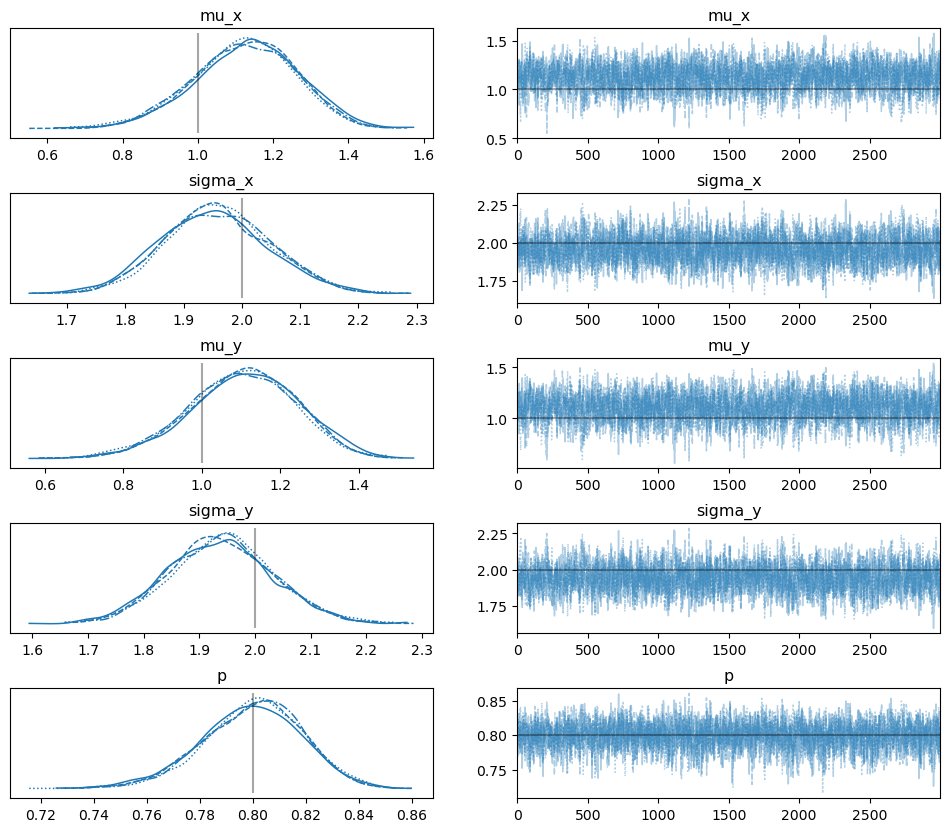

In [18]:
axes=az.plot_trace(            
        trace,
        compact=True,
        var_names=['mu_x', 'sigma_x','mu_y','sigma_y','p'],
        lines=[
            ('mu_x', {}, mu_t_x),         # original mu_P
            ('sigma_x', {}, sigma_t_x),   # original sigma_P
            ('mu_y', {}, mu_t_y),         # original mu_P
            ('sigma_y', {}, sigma_t_y),
            ('p', {}, p_t)
        ]
    )
fig = axes.ravel()[0].figure.subplots_adjust(hspace=0.5)
az.summary(trace)

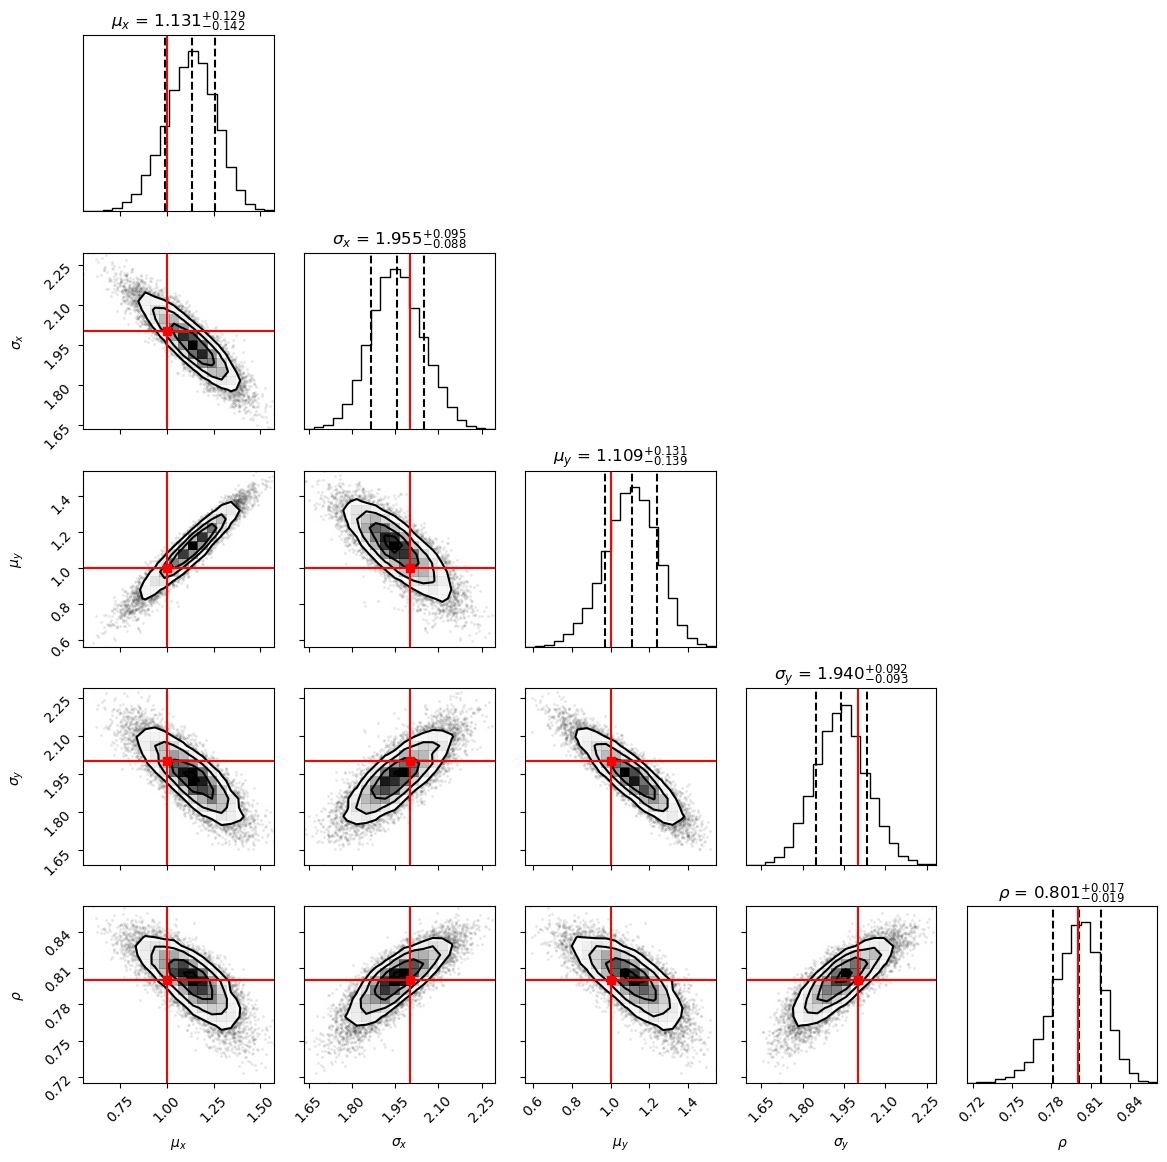

In [19]:

posterior=az.extract(trace,var_names=["mu_x","sigma_x","mu_y","sigma_y","p"],combined=True)

samples=np.column_stack([
posterior["mu_x"].values,
posterior["sigma_x"].values,
posterior["mu_y"].values,
posterior["sigma_y"].values,
posterior["p"].values
])

fig=corner.corner(
samples,
labels=[r"$\mu_x$",r"$\sigma_x$",r"$\mu_y$",r"$\sigma_y$",r"$\rho$"],
truths=[mu_t_x,sigma_t_x,mu_t_y,sigma_t_y,p_t],
truth_color="red",
show_titles=True,
quantiles=[0.16,0.5,0.84],
title_fmt=".3f"
)

plt.tight_layout()
plt.show()